# Preliminaries

In [3]:
import numpy as np
import numpy.polynomial.polynomial as poly

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec

import scipy.constants as const
from scipy.signal import fftconvolve, welch
import scipy.optimize as optimize

import pycbc.psd, pycbc.filter, pycbc.noise
from pycbc.types import TimeSeries

plt.rcParams['text.usetex'] = True

#define the solar mass in [kg] and parsec in [meters]
sol = 1.989e30
pc = 3.086e16

/opt/anaconda3/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [4]:
#for the waveforms of the quasi-circular binary system and quasi-circular Lagrange triple
import waveforms

print(waveforms.CircularBinary.__doc__)
print(waveforms.CircularLagrangeTriple.__doc__)

CircularBinary contains the waveforms for a quasi-circular binary system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence [rad]
    

    CircularLagrangeTriple contains the waveforms for a quasi-circular Lagrange three-body system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2, m3 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence

# 1: Function Definitions

The following functions are for calculating the parameters of the Lagrange triple that give out the same waveform as that of a given binary system.

In [7]:
def findQuadDegeneracy_plus(a, m1_2B, m2_2B, r_2B, i_2B_deg, M_3B, beta_1, i_3B_deg, atol = 1e-23):
    #initialize binary
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, 0)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    i_2B = np.radians(i_2B_deg)

    #free parameters of the Lagrange triple
    M_3B *= sol
    i_3B = np.radians(i_3B_deg)

    #parameters to solve
    r_3B = ((M_3B/binary.M_c)**(5/3))*(binary.r*beta_1*np.abs(3*beta_1 - 1)*(1 + (np.cos(i_3B))**2))/(1 + (np.cos(i_2B))**2)
    b = (const.G*M_3B/(w_2B**2))**(1/3)

    #find the appropriate integration constant Phi_c
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    for phi in shift:
        temp = [b/pc, M_3B*beta_1/sol, M_3B*beta_1/sol, M_3B*(1 - 2*beta_1)/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_quad(t_max = 1, radRxn = True, pol = "plus")[:4] - lagrange.h_quad(t_max = 1, radRxn = True, pol = "plus")[:4])
            
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi

    #return b and r_3B in [pc]
    return b/pc, r_3B/pc, phi_3B

def findQuadDegeneracy_cross(a, m1_2B, m2_2B, r_2B, i_2B_deg, M_3B, beta_1, i_3B_deg, atol = 1e-23):
    #initialize binary
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, 0)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    i_2B = np.radians(i_2B_deg)

    #free parameters of the Lagrange triple
    M_3B *= sol
    i_3B = np.radians(i_3B_deg)

    #parameters to solve
    r_3B = ((M_3B/binary.M_c)**(5/3))*(binary.r*beta_1*np.abs(3*beta_1 - 1)*np.cos(i_3B))/np.cos(i_2B)
    b = (const.G*M_3B/(w_2B**2))**(1/3)

    #find the appropriate integration constant Phi_c
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    for phi in shift:
        temp = [b/pc, M_3B*beta_1/sol, M_3B*beta_1/sol, M_3B*(1 - 2*beta_1)/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_quad(t_max = 1, radRxn = True, pol = "cross")[:4] - lagrange.h_quad(t_max = 1, radRxn = True, pol = "cross")[:4])
            
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi

    #return b and r_3B in [pc]
    return b/pc, r_3B/pc, phi_3B

def F(b1, b2):
    num = 3*((b1 + b2 - 1)**2)*((2*b1**2 + (b1 + b2)*(2*b2 - 1))**2) + (b1 - 3*b1**2 + 2*b1**3 + b2*(b2*(3 - 2*b2) - 1))**2
    denom = 27*(b1**2)*(b2**2)*((b1 + b2 - 1)**2) + ((b1 - b2)**2)*((2*b1 + b2 - 1)**2)*((b1 + 2*b2 - 1)**2)

    return np.sqrt(num/denom)

def iota(b1, b2, ratio_w_3w):
    return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))

def find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    b3 = 1 - 2*b1
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))

    term1 = (np.sqrt(3)*b3/8)*(amp_quadPlus_2B/amp_octcqPlus_2B_w)*(np.sin(i_3B)*(5 + np.cos(i_3B)**2)/(1 + np.cos(i_3B)**2))*((w_2B/const.c)**(1/3))
    term2 = (9*np.sqrt(27)/8)*(b1*b3/np.abs(b1 - b3))*(amp_quadPlus_2B/amp_octcqPlus_2B_3w)*np.sin(i_3B)*((w_2B/const.c)**(1/3))

    return ((const.c**2)/const.G) * ((1/2)*(term1**(-3)) + (1/2)*(term2**(-3)))

def find_r(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    t = np.linspace(0, 1000, 10000)
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))
    b3 = 1 - 2*b1
    M_3B = find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1)

    term1 = 2*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(b1 - b3)*(1 + np.cos(i_3B)**2)
    term2 = (np.sqrt(3)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*b1*b3*np.abs(b1 - b3)*np.sin(i_3B)*(5 + np.cos(i_3B)**2)
    term3 = (9*np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*(b1**2)*b3*np.sin(i_3B)*(1 + np.cos(i_3B)**2)
    
    return (term1 + term2 + term3)/(amp_quadPlus_2B + amp_octcqPlus_2B_w + amp_octcqPlus_2B_3w)

def findOctDegeneracy_plus(params_binary, beta_1, filename = "", radRxn = False, suppressPrint = False, atol = 1e-23):
    #initialization
    binary = waveforms.CircularBinary(*params_binary)
    
    #generate the data
    ratio_w_3w = binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[0]/binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[1]
    
    b1 = np.linspace(0, 1, 500000)
    b2 = np.linspace(0, 1, 500000)
    i_3B = iota(b1, b2, ratio_w_3w)
    i_3B[b1 > 0.5] = np.nan
    
    #plot M_3B and r_3B for the given binary system
    #find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
    b1_filtered = b1[np.where(~np.isnan(i_3B))]

    if suppressPrint == False:
        print("Min beta_1 for true degeneracy = {}".format(b1_filtered[0]))
        print("Max beta_1 for true degeneracy = {}".format(b1_filtered[-1]))

    if b1_filtered[0] < beta_1 < b1_filtered[-1]:
        #calculate the parameters obtainable from the given binary system      
        w_2B = np.sqrt(const.G*(params_binary[1]*sol + params_binary[2]*sol)/((params_binary[0]*pc)**3))

        #find the parameters of the equivalent Lagrange triple
        M_3B = find_M_3B(*params_binary, beta_1)
        r_3B = find_r(*params_binary, beta_1)
        b = (const.G*M_3B/(w_2B**2))**(1/3)
        m1_3B = M_3B*beta_1
        m3_3B = M_3B - 2*m1_3B
        i_3B_deg = iota(beta_1, beta_1, ratio_w_3w)

        delta_t = 1/5000
        t_max = 3
        phi_3B = 0
        shift = np.linspace(0, 2*np.pi, 1000)

        for phi in shift:
            temp = [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi]
            lagrange = waveforms.CircularLagrangeTriple(*temp)
            check = np.abs(binary.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4] - lagrange.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4])
            
            if all(np.isclose(check, 0, atol = atol)):
                phi_3B = phi

        #compile the parameters of the triple into one list
        return [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi_3B]
    else:
        print("Mass ratio not in the region for true degeneracy.")


def octDegeneracy_cross_equations(init, params_binary, beta_1):
    #initial conditions must be in SI units (distances in [m], masses in [kg], angles in [rad])
    r_3B, M_3B, i_3B = init
    b1 = beta_1
    binary = waveforms.CircularBinary(*params_binary)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))

    eq1 = binary.h_quad(1, ampOnly = True, pol = "cross") - 4*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(3*b1 - 1)*np.cos(i_3B)/r_3B
    eq2 = binary.h_octcq(1, ampOnly = True, pol = "cross")[0] - (np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*b1*(1 - 2*b1)*np.abs(3*b1 - 1)*np.sin(2*i_3B)/r_3B
    eq3 = binary.h_octcq(1, ampOnly = True, pol = "cross")[1] - (9*np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*(b1**2)*(1 - 2*b1)*np.sin(2*i_3B)/r_3B
    
    return [eq1, eq2, eq3]

def findOctDegeneracy_cross(init, a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, beta_1, method = "lm", root_tol = 1e-25, atol = 1e-23):
    binary = waveforms.CircularBinary(*[a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B])
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    
    #input initial conditions for root finding must be in pc and solar masses
    #r_3B in [m], M_3B in [kg], and i_3B in [rad]
    solved_params_3B = optimize.root(octDegeneracy_cross_equations, [init[0]*pc, init[1]*sol, np.radians(init[2])],
                            method = method, tol = root_tol, args = ([a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B], beta_1))
    print(solved_params_3B.message)
    r_3B, M_3B, i_3B = solved_params_3B.x
    b = (const.G*M_3B/(w_2B**2))**(1/3)
    m1_3B = M_3B*beta_1
    m3_3B = M_3B - 2*m1_3B
    i_3B_deg = np.degrees(i_3B)

    delta_t = 1/5000
    t_max = 3
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    
    for phi in shift:
        temp = [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_octcq(t_max, delta_t, radRxn = True, pol = "cross")[:4] - lagrange.h_octcq(t_max, delta_t, radRxn = True, pol = "cross")[:4])
                
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi
    
    return [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi_3B]

# 2: Waveform Matching and SNR Calculations

One way to determine the similarity between waveforms is to use an inner product weighted by the noise spectral density of LIGO. In `PyCBC`, this is implemented using `pycbc.filter.match`. First, we show a plot of the PSD of the advanced LIGO design.

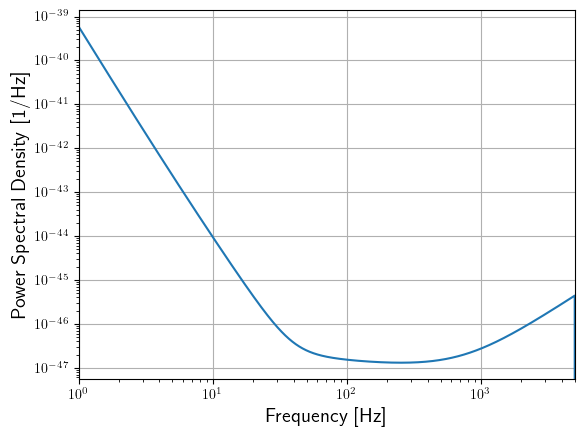

In [10]:
delta_f = 1.0 / 1000
flen = int(5000 / delta_f)
low_frequency_cutoff = 1

psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(flen, delta_f, low_frequency_cutoff)

plt.plot(psd.sample_frequencies, psd)

plt.xlabel("Frequency [Hz]", fontsize = "x-large")
plt.ylabel("Power Spectral Density [1/Hz]", fontsize = "x-large")
plt.xscale("log")
plt.yscale("log")
plt.xlim(xmin = low_frequency_cutoff, xmax = 5000)

plt.grid()
plt.gca().set_axisbelow(True)

plt.show()

## Waveform Degeneracy up to the Mass Quadrupole

In [18]:
params_2B = [1.50e-10, 10, 8, 2e6, 30, 0]
binary = waveforms.CircularBinary(*params_2B)

print("Binary chirp mass in solar mass = {}".format(waveforms.CircularBinary(*params_2B).M_c/sol))
print("Binary chirp starting frequency = {} Hz".format(binary.f_0))
print("Coalescence time = {} s".format(binary.t_c))

Binary chirp mass in solar mass = 7.776774233174123
Binary chirp starting frequency = 0.7811705577629253 Hz
Coalescence time = 6446.118194246173 s


Binary Parameters:
l = 1.5e-10, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.823108086643083e-10, m1 = 1.7999999999999998, m2 = 1.7999999999999998, m3 = 116.39999999999999, r = 2740065.1206373814, i = 30, phi = 4.9561061281856995

Binary Coalescence: 6446.118194246173
Lagrange Triple Coalescence: 9631.873402104025



(np.float64(0.9999997195966824), np.float64(-0.00045150549270238095))

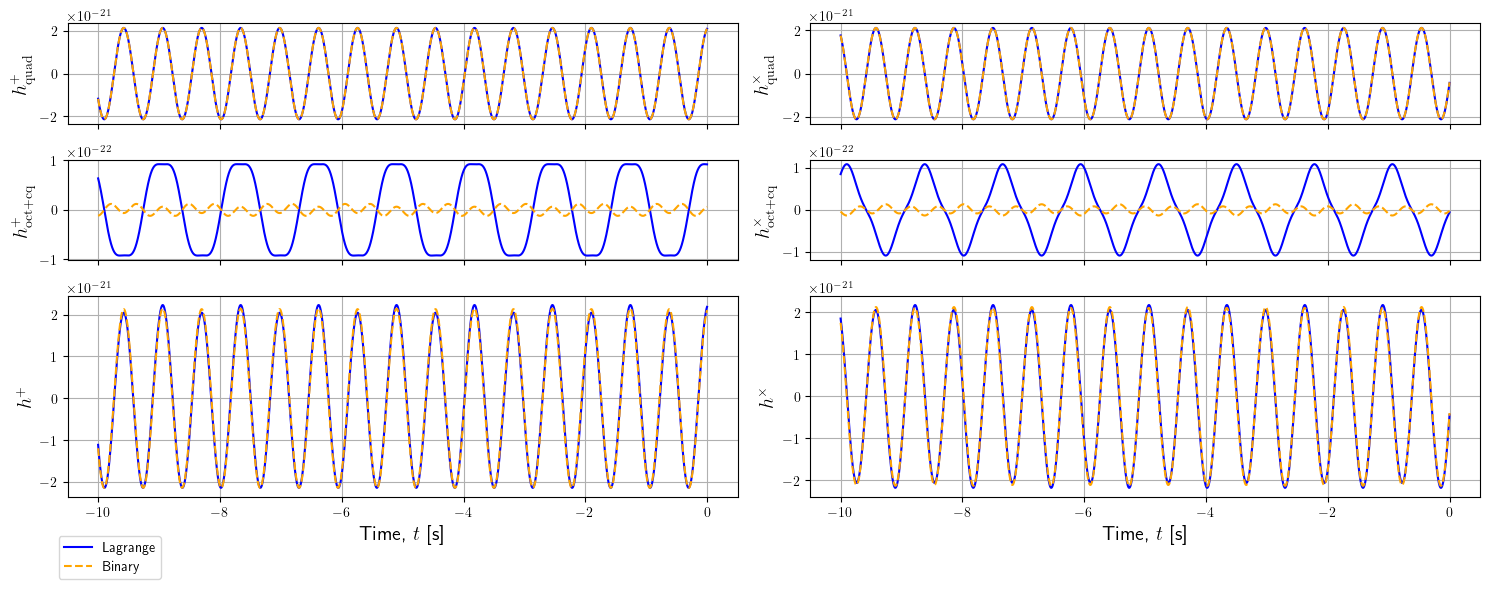

In [28]:
delta_t = 1/1000
t_max = 10

beta_1 = 0.015
M_3B = 120
i_3B = 30
quad_result = findQuadDegeneracy_plus(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-23)
params_3B_quad1 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time_combined(params_2B, params_3B_quad1, t_max = t_max, delta_t = delta_t, radRxn = True)

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

Binary Parameters:
l = 1.5e-10, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.041100997786697e-10, m1 = 2.25, m2 = 2.25, m3 = 145.5, r = 3974454.8960382254, i = 30, phi = 5.182527220336315

Binary Coalescence: 6446.118194246173
Lagrange Triple Coalescence: 6640.397499996262



(np.float64(0.9999997811700516), np.float64(-0.00011374793190769064))

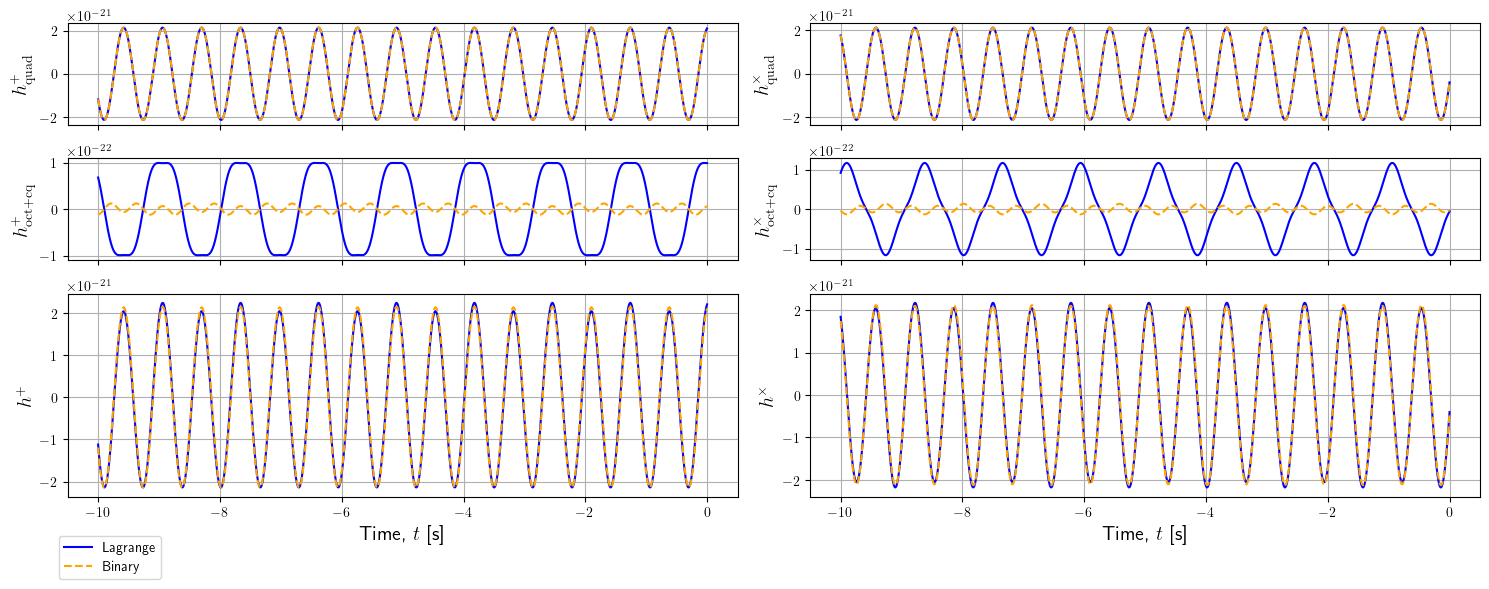

In [30]:
delta_t = 1/1000
t_max = 10

beta_1 = 0.015
M_3B = 150
i_3B = 30
quad_result = findQuadDegeneracy_plus(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-23)
params_3B_quad2 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad2, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time_combined(params_2B, params_3B_quad2, t_max = t_max, delta_t = delta_t, radRxn = True)

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad2).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

We also perform the waveform match in the case where the binary and the Lagrange triple (with a total mass of 150 ${\mathrm{M}}_{\odot} \gg \mathcal{M}_{\mathrm{(2B)}} = 7.776$) have the same quadrupole waveforms and chirp mass. As a consequence of the latter, both waveforms have the same frequency sweep.

Binary Parameters:
l = 1.5e-10, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.041100997786697e-10, m1 = 2.3231939027306483, m2 = 2.3231939027306483, m3 = 145.3536121945387, r = 4097455.9368759324, i = 30, phi = 6.283185307179586

Binary Coalescence: 6446.118194246173
Lagrange Triple Coalescence: 6446.118194246186



(np.float64(0.9999997647632085), np.float64(-0.0002378116096095107))

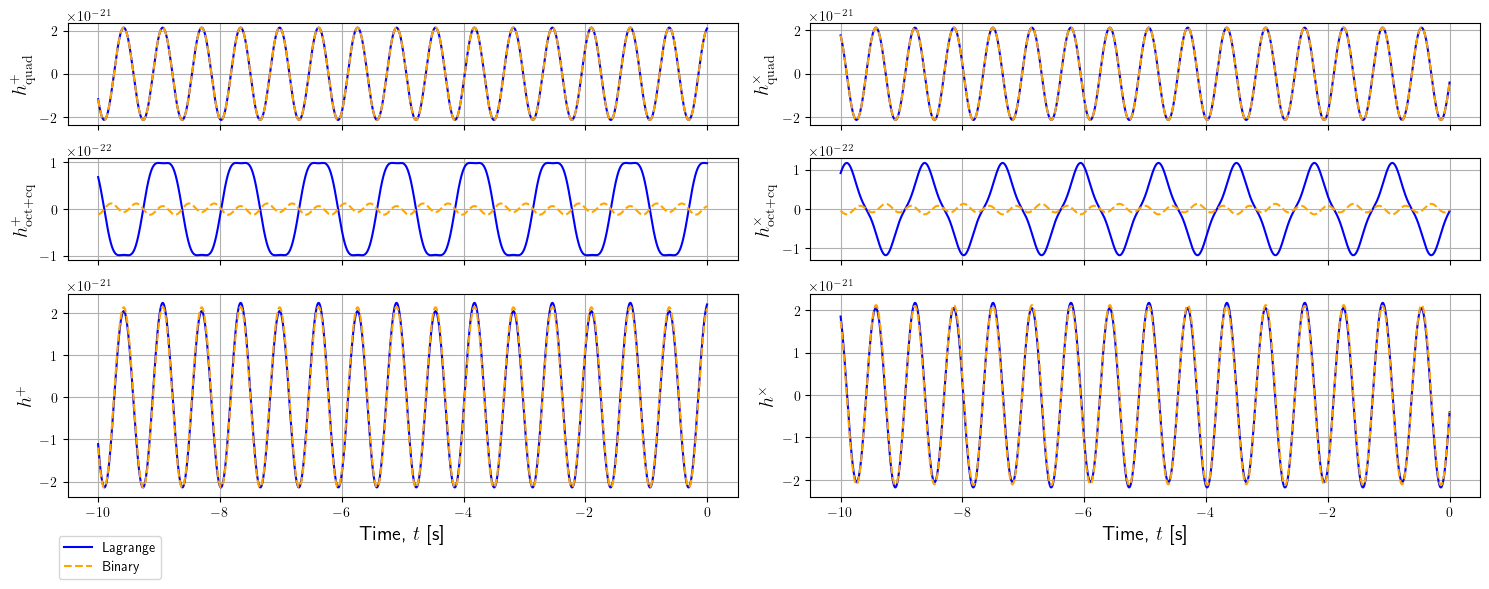

In [32]:
M_3B = 150
val = (waveforms.CircularBinary(*params_2B).M_c/sol)/M_3B

temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
temp = temp[np.isclose(temp.imag, 0)]
temp = temp[temp > 0]

beta_1 = np.real(np.min(temp))
i_3B = 30
quad_result = findQuadDegeneracy_plus(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-22)
params_3B_quad3 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad3, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time_combined(params_2B, params_3B_quad3, t_max = t_max, delta_t = delta_t, radRxn = True)

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad3).t_c))
print()

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

## Waveform Match Time Series for Mass Quadrupole Degeneracy

We also check how the waveform match depends on the parameters. Note that since the waveform match 

Binary Parameters:
l = 1.5e-10, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.041100997786697e-10, m1 = 2.3231939027306483, m2 = 2.3231939027306483, m3 = 145.3536121945387, r = 8194911.873751865, i = 30, phi = 6.283185307179586

Binary Coalescence: 6446.118194246173
Lagrange Triple Coalescence: 6446.118194246186



(np.float64(0.9999997647632085), np.float64(-0.0002378116096095107))

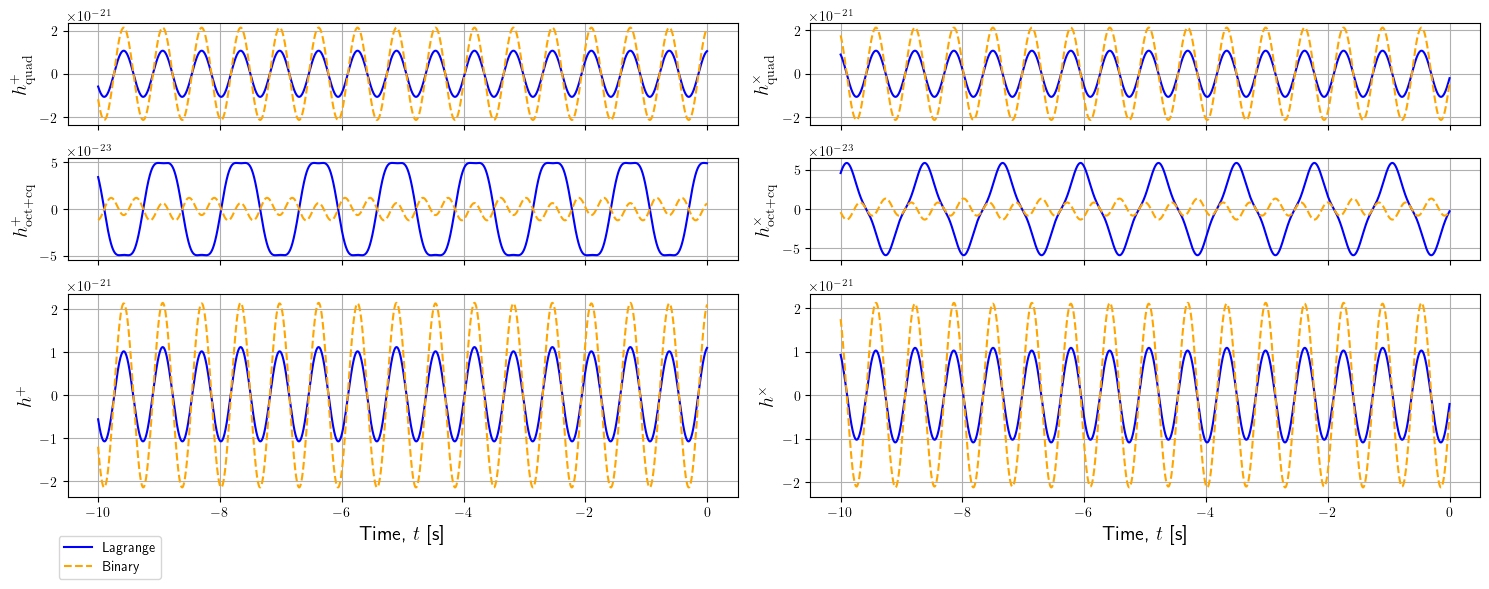

In [74]:
M_3B = 150
val = (waveforms.CircularBinary(*params_2B).M_c/sol)/M_3B

temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
temp = temp[np.isclose(temp.imag, 0)]
temp = temp[temp > 0]

beta_1 = np.real(np.min(temp))
i_3B = 30
quad_result = findQuadDegeneracy_plus(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-22)
params_3B_quad3 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), 2*quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad3, t_max = t_max, delta_t = delta_t) 

waveforms.plot_waveform_time_combined(params_2B, params_3B_quad3, t_max = t_max, delta_t = delta_t, radRxn = True,
                                     filename = "Test.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad3).t_c))
print()

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

A plot of the waveform match time series for the symmetric binary used above is shown below.

0.9836013008720224


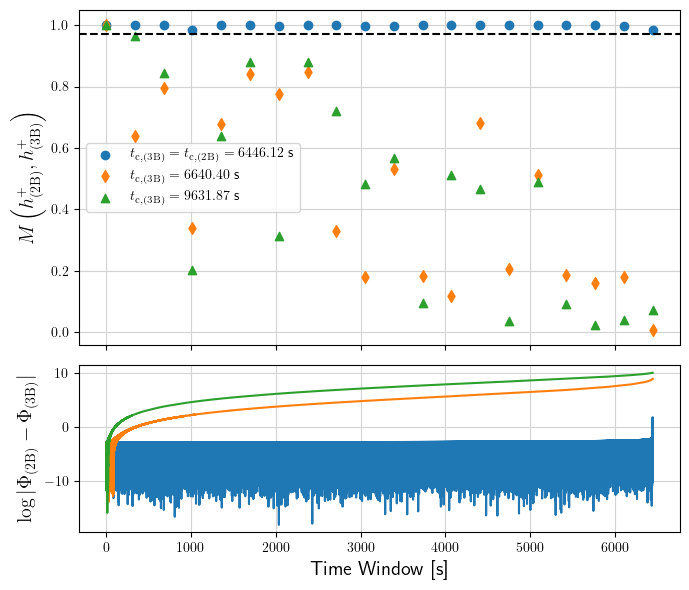

In [44]:
binary = waveforms.CircularBinary(*params_2B)
params_3B_quad = [params_3B_quad3, params_3B_quad2, params_3B_quad1]
markers = ["o", "d", "^", "X"]

t_window = np.linspace(0.01, binary.t_c, 20)

fig, (a1, a2) = plt.subplots(nrows = 2, ncols = 1, gridspec_kw = {'height_ratios': [2, 1]}, sharex = True, figsize = (7, 6))

for i in range(len(params_3B_quad)):
    match_timeSeries = np.zeros(len(t_window))
    
    for j in range(len(t_window)):
        lagrange = waveforms.CircularLagrangeTriple(*params_3B_quad[i])

        #get the plus and cross polarizations
        hp_2B_windowed, hc_2B_windowed = waveforms.h_combined2B(*params_2B, t_max = t_window[j], delta_t = 1/1000)
        hp_3B_windowed, hc_3B_windowed = waveforms.h_combined3B(*params_3B_quad[i], t_max = t_window[j], delta_t = 1/1000)

        #calculate match
        psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B_windowed) // 2 + 1, 1.0 / hp_2B_windowed.duration, 0)
        match_timeSeries[j] = pycbc.filter.match(hp_2B_windowed, hp_3B_windowed, psd = psd, low_frequency_cutoff = 0, subsample_interpolation = True)[0]

    #calculate phase difference
    hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_window[-1], delta_t = 1/1000)
    hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad[i], t_max = t_window[-1], delta_t = 1/1000)
    h_phase_2B = np.unwrap(np.angle(hp_2B + 1j*hc_2B), discont = np.pi + 0.5)
    h_phase_3B = np.unwrap(np.angle(hp_3B + 1j*hc_3B), discont = np.pi + 0.5)
    phaseDiff_timeSeries = np.log(np.abs(h_phase_2B - h_phase_3B))
        
    if i == 0:
        #print(match_timeSeries)
        a1.scatter(t_window, match_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = t_{{\mathrm{{c,(2B)}}}} = {:.2f}$ s".format(lagrange.t_c), marker = markers[i])
        a2.plot(hp_2B.sample_times + binary.t_c, phaseDiff_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = t_{{\mathrm{{c,(2B)}}}} = {:.2f}$ s".format(lagrange.t_c))
        print(match_timeSeries[-1])
    else:
        a1.scatter(t_window, match_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = {:.2f}$ s".format(lagrange.t_c), marker = markers[i])
        a2.plot(hp_2B.sample_times + binary.t_c, phaseDiff_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = {:.2f}$ s".format(lagrange.t_c))

a1.legend()
#a1.set_xlabel("Time Window [s]", fontsize = "x-large")
a1.set_ylabel(r"$M\left(h^{+}_{\mathrm{(2B)}}, h^{+}_{\mathrm{(3B)}}\right)$", fontsize = "x-large")
#a1.set_xlim(0.01, 0.65)
a1.axhline(0.97, 0, 1, ls = "--", color = "black")
a1.grid(color = "lightgray")
a1.set_axisbelow(True)

#a2.legend()
a2.set_xlabel("Time Window [s]", fontsize = "x-large")
a2.set_ylabel(r"$\log | \Phi_{\mathrm{(2B)}} - \Phi_{\mathrm{(3B)}} |$", fontsize = "x-large")
#a2.set_yscale("log")
a2.grid(color = "lightgray")
a2.set_axisbelow(True)

plt.tight_layout()

plt.show()

0.9885975570840876


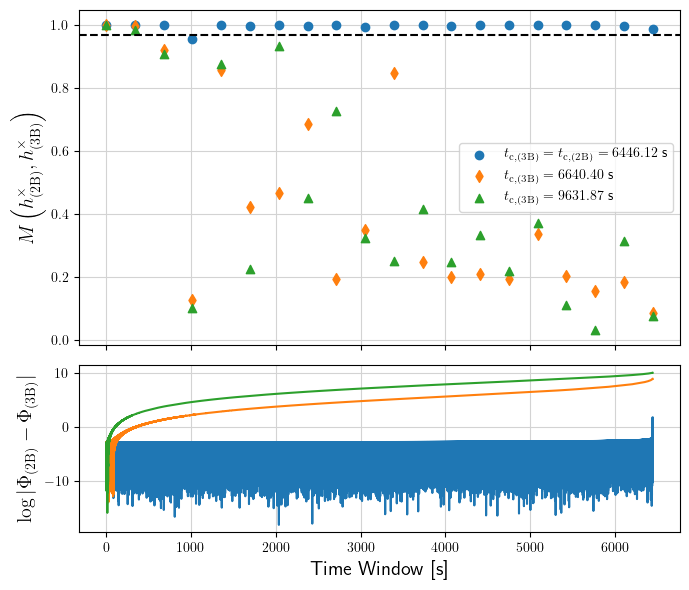

In [42]:
binary = waveforms.CircularBinary(*params_2B)
params_3B_quad = [params_3B_quad3, params_3B_quad2, params_3B_quad1]
markers = ["o", "d", "^", "X"]

t_window = np.linspace(0.01, binary.t_c, 20)

fig, (a1, a2) = plt.subplots(nrows = 2, ncols = 1, gridspec_kw = {'height_ratios': [2, 1]}, sharex = True, figsize = (7, 6))

for i in range(len(params_3B_quad)):
    match_timeSeries = np.zeros(len(t_window))
    
    for j in range(len(t_window)):
        lagrange = waveforms.CircularLagrangeTriple(*params_3B_quad[i])

        #get the plus and cross polarizations
        hp_2B_windowed, hc_2B_windowed = waveforms.h_combined2B(*params_2B, t_max = t_window[j], delta_t = 1/1000)
        hp_3B_windowed, hc_3B_windowed = waveforms.h_combined3B(*params_3B_quad[i], t_max = t_window[j], delta_t = 1/1000)

        #calculate match
        psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hc_2B_windowed) // 2 + 1, 1.0 / hp_2B_windowed.duration, 0)
        match_timeSeries[j] = pycbc.filter.match(hc_2B_windowed, hc_3B_windowed, psd = psd, low_frequency_cutoff = 0, subsample_interpolation = True)[0]

    #calculate phase difference
    hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_window[-1], delta_t = 1/1000)
    hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad[i], t_max = t_window[-1], delta_t = 1/1000)
    h_phase_2B = np.unwrap(np.angle(hp_2B + 1j*hc_2B))
    h_phase_3B = np.unwrap(np.angle(hp_3B + 1j*hc_3B))
    phaseDiff_timeSeries = np.log(np.abs(h_phase_2B - h_phase_3B))
        
    if i == 0:
        #print(match_timeSeries)
        a1.scatter(t_window, match_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = t_{{\mathrm{{c,(2B)}}}} = {:.2f}$ s".format(lagrange.t_c), marker = markers[i])
        a2.plot(hp_2B.sample_times + binary.t_c, phaseDiff_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = t_{{\mathrm{{c,(2B)}}}} = {:.2f}$ s".format(lagrange.t_c))
        print(match_timeSeries[-1])
    else:
        a1.scatter(t_window, match_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = {:.2f}$ s".format(lagrange.t_c), marker = markers[i])
        a2.plot(hp_2B.sample_times + binary.t_c, phaseDiff_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = {:.2f}$ s".format(lagrange.t_c))

a1.legend()
#a1.set_xlabel("Time Window [s]", fontsize = "x-large")
a1.set_ylabel(r"$M\left(h^{\times}_{\mathrm{(2B)}}, h^{\times}_{\mathrm{(3B)}}\right)$", fontsize = "x-large")
#a1.set_xlim(0.01, 0.65)
a1.axhline(0.97, 0, 1, ls = "--", color = "black")
a1.grid(color = "lightgray")
a1.set_axisbelow(True)

#a2.legend()
a2.set_xlabel("Time Window [s]", fontsize = "x-large")
a2.set_ylabel(r"$\log | \Phi_{\mathrm{(2B)}} - \Phi_{\mathrm{(3B)}} |$", fontsize = "x-large")
#a2.set_yscale("log")
a2.grid(color = "lightgray")
a2.set_axisbelow(True)

plt.tight_layout()

plt.show()

## Mass Asymmetry and Mass Quadrupole Degeneracy

We can also calculate the how the waveform match of degenerate systems up to the coalescence time evolve as the mass difference in the binary increases. We expect that as the mass difference in the binary grows larger, the waveform match decreases due to the increasing effect of the 0.5PN to the total waveform.

### $M_{\mathrm{(2B)}} = 10 \ \mathrm{M}_{\odot}$

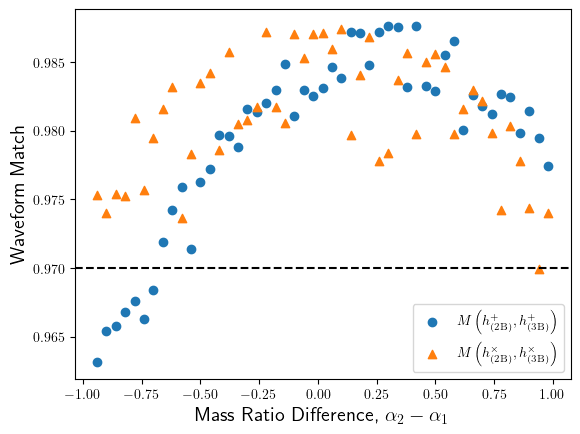

In [193]:
M_2B = 10
alpha2_vals = np.arange(0.99, 0.01, -0.02)

#free parameters of the Lagrange triple
M_3B = 150
i_3B = 30

#create list to store the waveform matches
match_massDiff_plus = np.zeros(len(alpha2_vals))
match_massDiff_cross = np.zeros(len(alpha2_vals))

#create list to store the parameters of the Lagrange triple for each iteration
params_3B_quad_massDiff = []

#create a list to store the different coalescence times
coalTime_massDiff = np.zeros(len(alpha2_vals))

for i in range(len(alpha2_vals)):
    params_2B_asymm_temp = [150e-13, M_2B*(1 - alpha2_vals[i]), alpha2_vals[i]*M_2B, 2e6, 30, 0]
    coalTime_massDiff[i] = waveforms.CircularBinary(*params_2B_asymm_temp).t_c

    #take the coalescence time to be the maximum time for the waveform match
    t_max = coalTime_massDiff[i]

    #find beta_1 so that the systems are degenerate up to the coalescence time
    val = (waveforms.CircularBinary(*params_2B_asymm_temp).M_c/sol)/M_3B
    root = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
    root = root[np.isclose(root.imag, 0)]
    root = root[root > 0]
    
    beta_1 = np.real(np.min(root))
    quad_result_temp = findQuadDegeneracy_plus(*params_2B_asymm_temp[:5], M_3B, beta_1, i_3B, atol = 1e-23)
    params_3B_quad_temp = [quad_result_temp[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result_temp[1], i_3B, quad_result_temp[2]]

    #store the parameters of the Lagrange triple
    params_3B_quad_massDiff.append(params_3B_quad_temp)
    
    #calculate the waveform
    hp_2B, hc_2B = waveforms.h_combined2B(*params_2B_asymm_temp, t_max = t_max, delta_t = delta_t)
    hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad_temp, t_max = t_max, delta_t = delta_t)

    #calculate waveform match
    f_lower = 0
    psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

    #store the waveform match
    match_massDiff_plus[i] = pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]
    match_massDiff_cross[i] = pycbc.filter.match(hc_2B, hc_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]

plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_plus, marker = "o",
            label = r"$M\left(h^{+}_{\mathrm{(2B)}}, h^{+}_{\mathrm{(3B)}}\right)$")
plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_cross, marker = "^",
            label = r"$M\left(h^{\times}_{\mathrm{(2B)}}, h^{\times}_{\mathrm{(3B)}}\right)$")
plt.xlabel(r"Mass Ratio Difference, $\alpha_2 - \alpha_1$", fontsize = "x-large")
plt.ylabel(r"Waveform Match", fontsize = "x-large")
plt.axhline(0.97, 0, 1, ls = "--", color = "black")

plt.legend(loc = "lower right")
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/Match vs Mass Ratio for MQ Degeneracy (M_2B = 10).pdf", bbox_inches = "tight")
plt.show()

In [205]:
for j in range(1, len(match_massDiff_plus) // 2):
    print("m1/M = {:.3f}, m2/M = {:.3f}, diff = {:.3f}, Match = {:.5f}".format(1 - alpha2_vals[j], alpha2_vals[j], alpha2_vals[j] - (1 - alpha2_vals[j]), match_massDiff_plus[j]))
    print("m1/M = {:.3f}, m2/M = {:.3f}, diff = {:.3f}, Match = {:.5f}".format(1 - alpha2_vals[len(match_massDiff_plus) - j], alpha2_vals[len(match_massDiff_plus) - j], alpha2_vals[len(match_massDiff_plus) - j] - (1 - alpha2_vals[len(match_massDiff_plus) - j]), match_massDiff_plus[len(match_massDiff_plus) - j]))
    if match_massDiff_plus[len(match_massDiff_plus) - j] < match_massDiff_plus[j]:
        print("Inversion decreases match")
    else:
        print("Inversion did not decrease match")
    
    print("\n")

m1/M = 0.030, m2/M = 0.970, diff = 0.940, Match = 0.97944
m1/M = 0.970, m2/M = 0.030, diff = -0.940, Match = 0.96316
Inversion decreases match


m1/M = 0.050, m2/M = 0.950, diff = 0.900, Match = 0.98140
m1/M = 0.950, m2/M = 0.050, diff = -0.900, Match = 0.96543
Inversion decreases match


m1/M = 0.070, m2/M = 0.930, diff = 0.860, Match = 0.97981
m1/M = 0.930, m2/M = 0.070, diff = -0.860, Match = 0.96580
Inversion decreases match


m1/M = 0.090, m2/M = 0.910, diff = 0.820, Match = 0.98245
m1/M = 0.910, m2/M = 0.090, diff = -0.820, Match = 0.96681
Inversion decreases match


m1/M = 0.110, m2/M = 0.890, diff = 0.780, Match = 0.98270
m1/M = 0.890, m2/M = 0.110, diff = -0.780, Match = 0.96757
Inversion decreases match


m1/M = 0.130, m2/M = 0.870, diff = 0.740, Match = 0.98125
m1/M = 0.870, m2/M = 0.130, diff = -0.740, Match = 0.96626
Inversion decreases match


m1/M = 0.150, m2/M = 0.850, diff = 0.700, Match = 0.98182
m1/M = 0.850, m2/M = 0.150, diff = -0.700, Match = 0.96839
Inversion dec

Binary 1: m1 = 0.700, m2 = 9.300
Binary 2: m1 = 9.300, m2 = 0.700


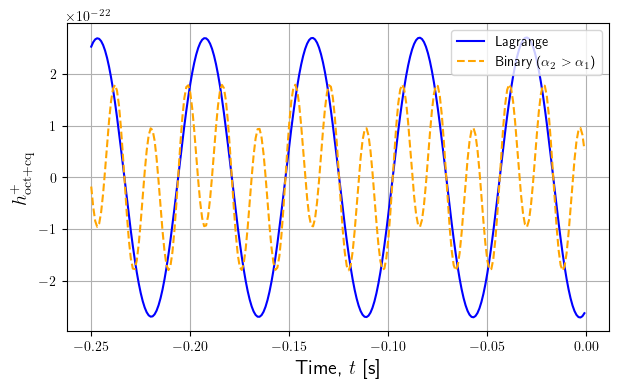

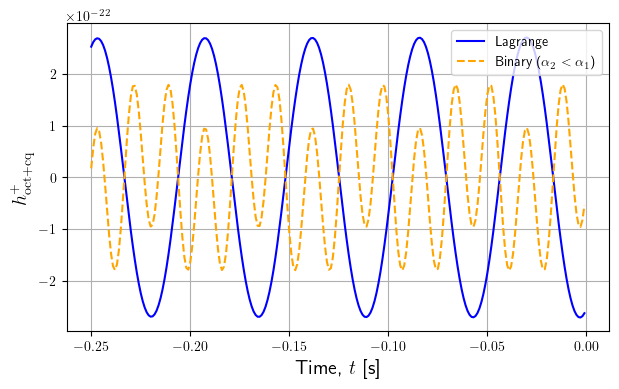

In [224]:
j = 3
t_max = 0.25

binary1_matchDiff_test = waveforms.CircularBinary(*[150e-13, M_2B*(1 - alpha2_vals[j]), alpha2_vals[j]*M_2B, 2e6, 30, 0])
lagrange1_matchDiff_test = waveforms.CircularLagrangeTriple(*params_3B_quad_massDiff[j])

binary2_matchDiff_test = waveforms.CircularBinary(*[150e-13, M_2B*alpha2_vals[j], M_2B*(1 - alpha2_vals[j]), 2e6, 30, 0])
lagrange2_matchDiff_test = waveforms.CircularLagrangeTriple(*params_3B_quad_massDiff[49 - j])

print("Binary 1: m1 = {:.3f}, m2 = {:.3f}".format(binary1_matchDiff_test.m1/sol, binary1_matchDiff_test.m2/sol))
print("Binary 2: m1 = {:.3f}, m2 = {:.3f}".format(binary2_matchDiff_test.m1/sol, binary2_matchDiff_test.m2/sol))

plt.figure(figsize = (7, 4))
plt.plot(lagrange1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus").sample_times,
        lagrange1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus"),
        color = "blue", ls = "solid", label = r"Lagrange")
plt.plot(binary1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus").sample_times,
        binary1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus"),
        color = "orange", ls = "dashed", label = r"Binary ($\alpha_2 > \alpha_1$)")

plt.xlabel("Time, $t$ [s]", fontsize = "x-large")
plt.ylabel(r"$h^{+}_{\mathrm{oct+cq}}$", fontsize = "x-large")
plt.legend()
plt.grid()
plt.gca().set_axisbelow(True)
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/0.5PN Waveforms for MQ Degeneracy 1 (Plus, Original).pdf", bbox_inches = "tight")
plt.show()

plt.figure(figsize = (7, 4))
plt.plot(lagrange2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus").sample_times,
        lagrange2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus"),
        color = "blue", ls = "solid", label = r"Lagrange")
plt.plot(binary2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus").sample_times,
        binary2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus"),
        color = "orange", ls = "dashed", label = r"Binary ($\alpha_2 < \alpha_1$)")

plt.xlabel("Time, $t$ [s]", fontsize = "x-large")
plt.ylabel(r"$h^{+}_{\mathrm{oct+cq}}$", fontsize = "x-large")
plt.legend()
plt.grid()
plt.gca().set_axisbelow(True)
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/0.5PN Waveforms for MQ Degeneracy 1 (Plus, Inverted).pdf", bbox_inches = "tight")
plt.show()

In [207]:
for j in range(1, len(match_massDiff_cross) // 2):
    print("m1/M = {:.3f}, m2/M = {:.3f}, diff = {:.3f}, Match = {:.5f}".format(1 - alpha2_vals[j], alpha2_vals[j], alpha2_vals[j] - (1 - alpha2_vals[j]), match_massDiff_cross[j]))
    print("m1/M = {:.3f}, m2/M = {:.3f}, diff = {:.3f}, Match = {:.5f}".format(1 - alpha2_vals[len(match_massDiff_cross) - j], alpha2_vals[len(match_massDiff_cross) - j], alpha2_vals[len(match_massDiff_plus) - j] - (1 - alpha2_vals[len(match_massDiff_plus) - j]), match_massDiff_cross[len(match_massDiff_cross) - j]))
    if match_massDiff_cross[len(match_massDiff_cross) - j] < match_massDiff_cross[j]:
        print("Inversion decreases match")
    else:
        print("Inversion did not decrease match")
    
    print("\n")

m1/M = 0.030, m2/M = 0.970, diff = 0.940, Match = 0.96989
m1/M = 0.970, m2/M = 0.030, diff = -0.940, Match = 0.97532
Inversion did not decrease match


m1/M = 0.050, m2/M = 0.950, diff = 0.900, Match = 0.97440
m1/M = 0.950, m2/M = 0.050, diff = -0.900, Match = 0.97403
Inversion decreases match


m1/M = 0.070, m2/M = 0.930, diff = 0.860, Match = 0.97783
m1/M = 0.930, m2/M = 0.070, diff = -0.860, Match = 0.97536
Inversion decreases match


m1/M = 0.090, m2/M = 0.910, diff = 0.820, Match = 0.98031
m1/M = 0.910, m2/M = 0.090, diff = -0.820, Match = 0.97522
Inversion decreases match


m1/M = 0.110, m2/M = 0.890, diff = 0.780, Match = 0.97425
m1/M = 0.890, m2/M = 0.110, diff = -0.780, Match = 0.98092
Inversion did not decrease match


m1/M = 0.130, m2/M = 0.870, diff = 0.740, Match = 0.97982
m1/M = 0.870, m2/M = 0.130, diff = -0.740, Match = 0.97568
Inversion decreases match


m1/M = 0.150, m2/M = 0.850, diff = 0.700, Match = 0.98217
m1/M = 0.850, m2/M = 0.150, diff = -0.700, Match = 0.97946

Binary 1: m1 = 0.700, m2 = 9.300
Binary 2: m1 = 9.300, m2 = 0.700


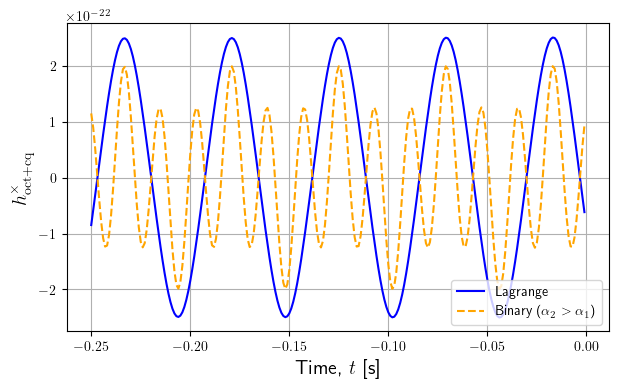

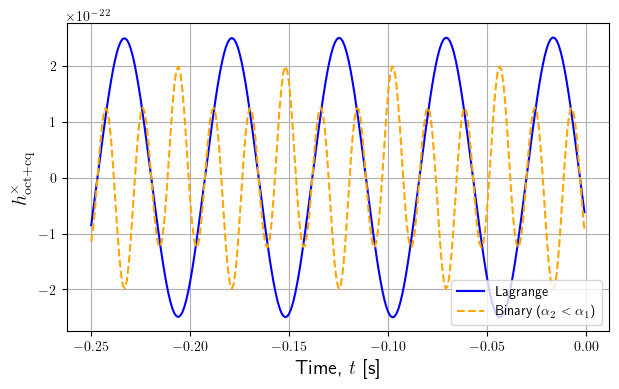

In [226]:
j = 3
t_max = 0.25

binary1_matchDiff_test = waveforms.CircularBinary(*[150e-13, M_2B*(1 - alpha2_vals[j]), alpha2_vals[j]*M_2B, 2e6, 30, 0])
lagrange1_matchDiff_test = waveforms.CircularLagrangeTriple(*params_3B_quad_massDiff[j])

binary2_matchDiff_test = waveforms.CircularBinary(*[150e-13, M_2B*alpha2_vals[j], M_2B*(1 - alpha2_vals[j]), 2e6, 30, 0])
lagrange2_matchDiff_test = waveforms.CircularLagrangeTriple(*params_3B_quad_massDiff[49 - j])

print("Binary 1: m1 = {:.3f}, m2 = {:.3f}".format(binary1_matchDiff_test.m1/sol, binary1_matchDiff_test.m2/sol))
print("Binary 2: m1 = {:.3f}, m2 = {:.3f}".format(binary2_matchDiff_test.m1/sol, binary2_matchDiff_test.m2/sol))

plt.figure(figsize = (7, 4))
plt.plot(lagrange1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross").sample_times,
        lagrange1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross"),
        color = "blue", ls = "solid", label = r"Lagrange")
plt.plot(binary1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross").sample_times,
        binary1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross"),
        color = "orange", ls = "dashed", label = r"Binary ($\alpha_2 > \alpha_1$)")

plt.xlabel("Time, $t$ [s]", fontsize = "x-large")
plt.ylabel(r"$h^{\times}_{\mathrm{oct+cq}}$", fontsize = "x-large")
plt.legend()
plt.grid()
plt.gca().set_axisbelow(True)
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/0.5PN Waveforms for MQ Degeneracy 1 (Cross, Original).pdf", bbox_inches = "tight")
plt.show()

plt.figure(figsize = (7, 4))
plt.plot(lagrange2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross").sample_times,
        lagrange2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross"),
        color = "blue", ls = "solid", label = r"Lagrange")
plt.plot(binary2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross").sample_times,
        binary2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross"),
        color = "orange", ls = "dashed", label = r"Binary ($\alpha_2 < \alpha_1$)")

plt.xlabel("Time, $t$ [s]", fontsize = "x-large")
plt.ylabel(r"$h^{\times}_{\mathrm{oct+cq}}$", fontsize = "x-large")
plt.legend()
plt.grid()
plt.gca().set_axisbelow(True)
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/0.5PN Waveforms for MQ Degeneracy 1 (Cross, Inverted).pdf", bbox_inches = "tight")
plt.show()

### $M_{\mathrm{(2B)}} = 20 \ \mathrm{M}_{\odot}$

/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:55: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:59: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:198: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:202: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)


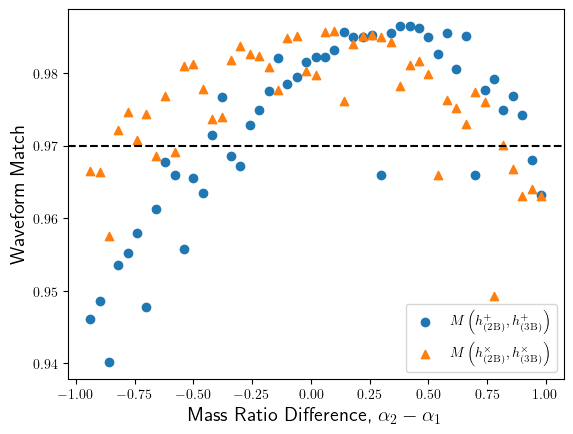

In [228]:
M_2B = 20
alpha2_vals = np.arange(0.99, 0.01, -0.02)

#free parameters of the Lagrange triple
M_3B = 150
i_3B = 30

#create list to store the waveform matches
match_massDiff_plus = np.zeros(len(alpha2_vals))
match_massDiff_cross = np.zeros(len(alpha2_vals))

#create list to store the parameters of the Lagrange triple for each iteration
params_3B_quad_massDiff = []

#create a list to store the different coalescence times
coalTime_massDiff = np.zeros(len(alpha2_vals))

for i in range(len(alpha2_vals)):
    params_2B_asymm_temp = [150e-13, M_2B*(1 - alpha2_vals[i]), alpha2_vals[i]*M_2B, 2e6, 30, 0]
    coalTime_massDiff[i] = waveforms.CircularBinary(*params_2B_asymm_temp).t_c

    #take the coalescence time to be the maximum time for the waveform match
    t_max = coalTime_massDiff[i]

    #find beta_1 so that the systems are degenerate up to the coalescence time
    val = (waveforms.CircularBinary(*params_2B_asymm_temp).M_c/sol)/M_3B
    root = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
    root = root[np.isclose(root.imag, 0)]
    root = root[root > 0]
    
    beta_1 = np.real(np.min(root))
    quad_result_temp = findQuadDegeneracy_plus(*params_2B_asymm_temp[:5], M_3B, beta_1, i_3B, atol = 1e-23)
    params_3B_quad_temp = [quad_result_temp[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result_temp[1], i_3B, quad_result_temp[2]]

    #store the parameters of the Lagrange triple
    params_3B_quad_massDiff.append(params_3B_quad_temp)
    
    #calculate the waveform
    hp_2B, hc_2B = waveforms.h_combined2B(*params_2B_asymm_temp, t_max = t_max, delta_t = delta_t)
    hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad_temp, t_max = t_max, delta_t = delta_t)

    #calculate waveform match
    f_lower = 0
    psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

    #store the waveform match
    match_massDiff_plus[i] = pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]
    match_massDiff_cross[i] = pycbc.filter.match(hc_2B, hc_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]

plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_plus, marker = "o",
            label = r"$M\left(h^{+}_{\mathrm{(2B)}}, h^{+}_{\mathrm{(3B)}}\right)$")
plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_cross, marker = "^",
            label = r"$M\left(h^{\times}_{\mathrm{(2B)}}, h^{\times}_{\mathrm{(3B)}}\right)$")
plt.xlabel(r"Mass Ratio Difference, $\alpha_2 - \alpha_1$", fontsize = "x-large")
plt.ylabel(r"Waveform Match", fontsize = "x-large")
plt.axhline(0.97, 0, 1, ls = "--", color = "black")

plt.legend(loc = "lower right")
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/Match vs Mass Ratio for MQ Degeneracy (M_2B = 20).pdf", bbox_inches = "tight")
plt.show()

In [230]:
for j in range(1, len(match_massDiff_plus) // 2):
    print("m1/M = {:.3f}, m2/M = {:.3f}, diff = {:.3f}, Match = {:.5f}".format(1 - alpha2_vals[j], alpha2_vals[j], alpha2_vals[j] - (1 - alpha2_vals[j]), match_massDiff_plus[j]))
    print("m1/M = {:.3f}, m2/M = {:.3f}, diff = {:.3f}, Match = {:.5f}".format(1 - alpha2_vals[len(match_massDiff_plus) - j], alpha2_vals[len(match_massDiff_plus) - j], alpha2_vals[len(match_massDiff_plus) - j] - (1 - alpha2_vals[len(match_massDiff_plus) - j]), match_massDiff_plus[len(match_massDiff_plus) - j]))
    if match_massDiff_plus[len(match_massDiff_plus) - j] < match_massDiff_plus[j]:
        print("Inversion decreases match")
    else:
        print("Inversion did not decrease match")
    
    print("\n")

m1/M = 0.030, m2/M = 0.970, diff = 0.940, Match = 0.96799
m1/M = 0.970, m2/M = 0.030, diff = -0.940, Match = 0.94618
Inversion decreases match


m1/M = 0.050, m2/M = 0.950, diff = 0.900, Match = 0.97419
m1/M = 0.950, m2/M = 0.050, diff = -0.900, Match = 0.94861
Inversion decreases match


m1/M = 0.070, m2/M = 0.930, diff = 0.860, Match = 0.97687
m1/M = 0.930, m2/M = 0.070, diff = -0.860, Match = 0.94022
Inversion decreases match


m1/M = 0.090, m2/M = 0.910, diff = 0.820, Match = 0.97488
m1/M = 0.910, m2/M = 0.090, diff = -0.820, Match = 0.95349
Inversion decreases match


m1/M = 0.110, m2/M = 0.890, diff = 0.780, Match = 0.97920
m1/M = 0.890, m2/M = 0.110, diff = -0.780, Match = 0.95514
Inversion decreases match


m1/M = 0.130, m2/M = 0.870, diff = 0.740, Match = 0.97770
m1/M = 0.870, m2/M = 0.130, diff = -0.740, Match = 0.95795
Inversion decreases match


m1/M = 0.150, m2/M = 0.850, diff = 0.700, Match = 0.96598
m1/M = 0.850, m2/M = 0.150, diff = -0.700, Match = 0.94782
Inversion dec

Binary 1: m1 = 1.400, m2 = 18.600
Binary 2: m1 = 18.600, m2 = 1.400


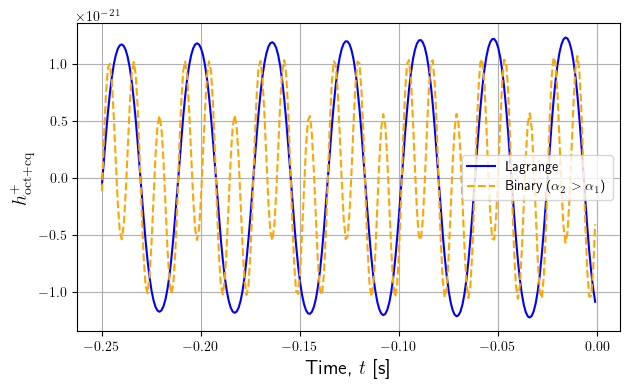

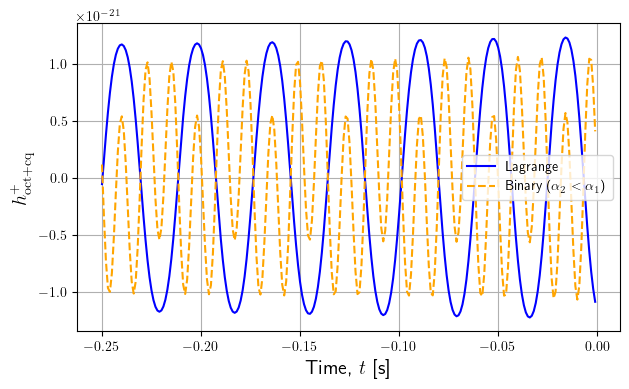

In [232]:
j = 3
t_max = 0.25

binary1_matchDiff_test = waveforms.CircularBinary(*[150e-13, M_2B*(1 - alpha2_vals[j]), alpha2_vals[j]*M_2B, 2e6, 30, 0])
lagrange1_matchDiff_test = waveforms.CircularLagrangeTriple(*params_3B_quad_massDiff[j])

binary2_matchDiff_test = waveforms.CircularBinary(*[150e-13, M_2B*alpha2_vals[j], M_2B*(1 - alpha2_vals[j]), 2e6, 30, 0])
lagrange2_matchDiff_test = waveforms.CircularLagrangeTriple(*params_3B_quad_massDiff[49 - j])

print("Binary 1: m1 = {:.3f}, m2 = {:.3f}".format(binary1_matchDiff_test.m1/sol, binary1_matchDiff_test.m2/sol))
print("Binary 2: m1 = {:.3f}, m2 = {:.3f}".format(binary2_matchDiff_test.m1/sol, binary2_matchDiff_test.m2/sol))

plt.figure(figsize = (7, 4))
plt.plot(lagrange1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus").sample_times,
        lagrange1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus"),
        color = "blue", ls = "solid", label = r"Lagrange")
plt.plot(binary1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus").sample_times,
        binary1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus"),
        color = "orange", ls = "dashed", label = r"Binary ($\alpha_2 > \alpha_1$)")

plt.xlabel("Time, $t$ [s]", fontsize = "x-large")
plt.ylabel(r"$h^{+}_{\mathrm{oct+cq}}$", fontsize = "x-large")
plt.legend()
plt.grid()
plt.gca().set_axisbelow(True)
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/0.5PN Waveforms for MQ Degeneracy 2 (Plus, Original).pdf", bbox_inches = "tight")
plt.show()

plt.figure(figsize = (7, 4))
plt.plot(lagrange2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus").sample_times,
        lagrange2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus"),
        color = "blue", ls = "solid", label = r"Lagrange")
plt.plot(binary2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus").sample_times,
        binary2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "plus"),
        color = "orange", ls = "dashed", label = r"Binary ($\alpha_2 < \alpha_1$)")

plt.xlabel("Time, $t$ [s]", fontsize = "x-large")
plt.ylabel(r"$h^{+}_{\mathrm{oct+cq}}$", fontsize = "x-large")
plt.legend()
plt.grid()
plt.gca().set_axisbelow(True)
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/0.5PN Waveforms for MQ Degeneracy 2 (Plus, Inverted).pdf", bbox_inches = "tight")
plt.show()

In [234]:
for j in range(1, len(match_massDiff_cross) // 2):
    print("m1/M = {:.3f}, m2/M = {:.3f}, diff = {:.3f}, Match = {:.5f}".format(1 - alpha2_vals[j], alpha2_vals[j], alpha2_vals[j] - (1 - alpha2_vals[j]), match_massDiff_cross[j]))
    print("m1/M = {:.3f}, m2/M = {:.3f}, diff = {:.3f}, Match = {:.5f}".format(1 - alpha2_vals[len(match_massDiff_cross) - j], alpha2_vals[len(match_massDiff_cross) - j], alpha2_vals[len(match_massDiff_cross) - j] - (1 - alpha2_vals[len(match_massDiff_cross) - j]), match_massDiff_cross[len(match_massDiff_cross) - j]))
    if match_massDiff_cross[len(match_massDiff_cross) - j] < match_massDiff_cross[j]:
        print("Inversion decreases match")
    else:
        print("Inversion did not decrease match")
    
    print("\n")

m1/M = 0.030, m2/M = 0.970, diff = 0.940, Match = 0.96400
m1/M = 0.970, m2/M = 0.030, diff = -0.940, Match = 0.96645
Inversion did not decrease match


m1/M = 0.050, m2/M = 0.950, diff = 0.900, Match = 0.96303
m1/M = 0.950, m2/M = 0.050, diff = -0.900, Match = 0.96642
Inversion did not decrease match


m1/M = 0.070, m2/M = 0.930, diff = 0.860, Match = 0.96677
m1/M = 0.930, m2/M = 0.070, diff = -0.860, Match = 0.95751
Inversion decreases match


m1/M = 0.090, m2/M = 0.910, diff = 0.820, Match = 0.97008
m1/M = 0.910, m2/M = 0.090, diff = -0.820, Match = 0.97209
Inversion did not decrease match


m1/M = 0.110, m2/M = 0.890, diff = 0.780, Match = 0.94934
m1/M = 0.890, m2/M = 0.110, diff = -0.780, Match = 0.97465
Inversion did not decrease match


m1/M = 0.130, m2/M = 0.870, diff = 0.740, Match = 0.97599
m1/M = 0.870, m2/M = 0.130, diff = -0.740, Match = 0.97070
Inversion decreases match


m1/M = 0.150, m2/M = 0.850, diff = 0.700, Match = 0.97731
m1/M = 0.850, m2/M = 0.150, diff = -0.700, M

Binary 1: m1 = 1.400, m2 = 18.600
Binary 2: m1 = 18.600, m2 = 1.400


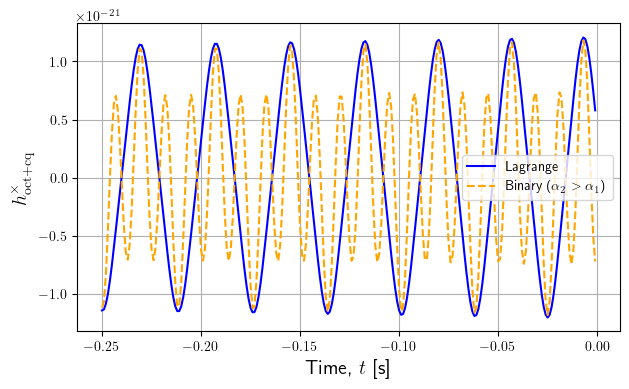

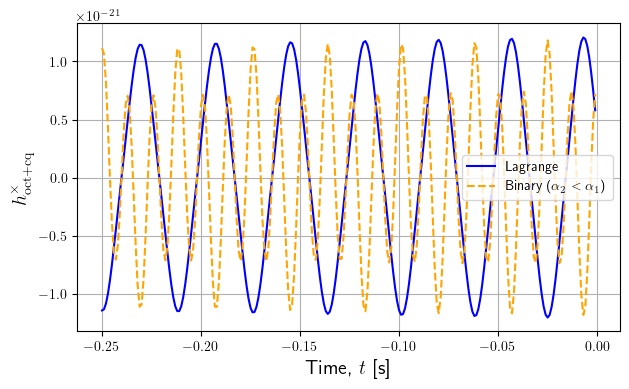

In [236]:
j = 3
t_max = 0.25

binary1_matchDiff_test = waveforms.CircularBinary(*[150e-13, M_2B*(1 - alpha2_vals[j]), alpha2_vals[j]*M_2B, 2e6, 30, 0])
lagrange1_matchDiff_test = waveforms.CircularLagrangeTriple(*params_3B_quad_massDiff[j])

binary2_matchDiff_test = waveforms.CircularBinary(*[150e-13, M_2B*alpha2_vals[j], M_2B*(1 - alpha2_vals[j]), 2e6, 30, 0])
lagrange2_matchDiff_test = waveforms.CircularLagrangeTriple(*params_3B_quad_massDiff[49 - j])

print("Binary 1: m1 = {:.3f}, m2 = {:.3f}".format(binary1_matchDiff_test.m1/sol, binary1_matchDiff_test.m2/sol))
print("Binary 2: m1 = {:.3f}, m2 = {:.3f}".format(binary2_matchDiff_test.m1/sol, binary2_matchDiff_test.m2/sol))

plt.figure(figsize = (7, 4))
plt.plot(lagrange1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross").sample_times,
        lagrange1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross"),
        color = "blue", ls = "solid", label = r"Lagrange")
plt.plot(binary1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross").sample_times,
        binary1_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross"),
        color = "orange", ls = "dashed", label = r"Binary ($\alpha_2 > \alpha_1$)")

plt.xlabel("Time, $t$ [s]", fontsize = "x-large")
plt.ylabel(r"$h^{\times}_{\mathrm{oct+cq}}$", fontsize = "x-large")
plt.legend()
plt.grid()
plt.gca().set_axisbelow(True)
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/0.5PN Waveforms for MQ Degeneracy 2 (Cross, Original).pdf", bbox_inches = "tight")
plt.show()

plt.figure(figsize = (7, 4))
plt.plot(lagrange2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross").sample_times,
        lagrange2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross"),
        color = "blue", ls = "solid", label = r"Lagrange")
plt.plot(binary2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross").sample_times,
        binary2_matchDiff_test.h_octcq(t_max = t_max, radRxn = True, pol = "cross"),
        color = "orange", ls = "dashed", label = r"Binary ($\alpha_2 < \alpha_1$)")

plt.xlabel("Time, $t$ [s]", fontsize = "x-large")
plt.ylabel(r"$h^{\times}_{\mathrm{oct+cq}}$", fontsize = "x-large")
plt.legend()
plt.grid()
plt.gca().set_axisbelow(True)
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/0.5PN Waveforms for MQ Degeneracy 2 (Cross, Inverted).pdf", bbox_inches = "tight")
plt.show()

### $M_{\mathrm{(2B)}} = 30 \ \mathrm{M}_{\odot}$

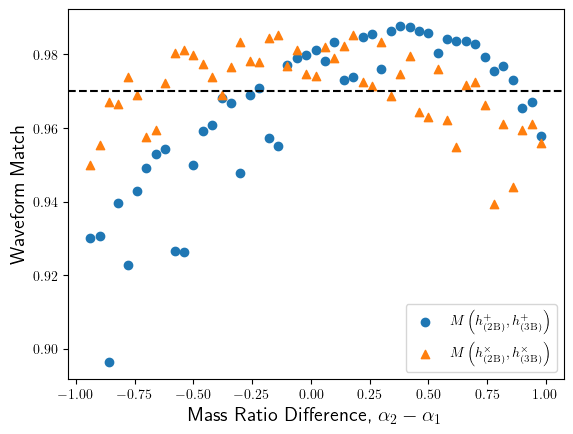

In [25]:
M_2B = 30
alpha2_vals = np.arange(0.99, 0.01, -0.02)

#free parameters of the Lagrange triple
M_3B = 150
i_3B = 30

match_massDiff_plus = np.zeros(len(alpha2_vals))
match_massDiff_cross = np.zeros(len(alpha2_vals))

for i in range(len(alpha2_vals)):
    params_2B_asymm_temp = [150e-13, M_2B*(1 - alpha2_vals[i]), alpha2_vals[i]*M_2B, 2e6, 30, 0]
    t_max = waveforms.CircularBinary(*params_2B_asymm_temp).t_c

    #find beta_1 so that the systems are degenerate up to the coalescence time
    val = (waveforms.CircularBinary(*params_2B_asymm_temp).M_c/sol)/M_3B
    root = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
    root = root[np.isclose(root.imag, 0)]
    root = root[root > 0]
    
    beta_1 = np.real(np.min(root))
    quad_result_temp = findQuadDegeneracy_plus(*params_2B_asymm_temp[:5], M_3B, beta_1, i_3B, atol = 1e-23)
    params_3B_quad_temp = [quad_result_temp[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result_temp[1], i_3B, quad_result_temp[2]]

    #calculate the waveform
    hp_2B, hc_2B = waveforms.h_combined2B(*params_2B_asymm_temp, t_max = t_max, delta_t = delta_t)
    hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad_temp, t_max = t_max, delta_t = delta_t)

    #calculate waveform match
    f_lower = 0
    psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)
    
    match_massDiff_plus[i] = pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]
    match_massDiff_cross[i] = pycbc.filter.match(hc_2B, hc_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)[0]

plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_plus, marker = "o",
            label = r"$M\left(h^{+}_{\mathrm{(2B)}}, h^{+}_{\mathrm{(3B)}}\right)$")
plt.scatter(alpha2_vals - (1 - alpha2_vals), match_massDiff_cross, marker = "^",
            label = r"$M\left(h^{\times}_{\mathrm{(2B)}}, h^{\times}_{\mathrm{(3B)}}\right)$")
plt.xlabel(r"Mass Ratio Difference, $\alpha_2 - \alpha_1$", fontsize = "x-large")
plt.ylabel(r"Waveform Match", fontsize = "x-large")
plt.axhline(0.97, 0, 1, ls = "--", color = "black")

plt.legend(loc = "lower right")
plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/Match vs Mass Ratio for MQ Degeneracy (M_2B = 30).pdf", bbox_inches = "tight")
plt.show()

## Waveform Degeneracy up to the 0.5PN Order

In [62]:
params_2B_asymm = [200e-13, 50, 1, 2e6, 5, 0]
print("Binary chirp mass in solar mass = {}".format(waveforms.CircularBinary(*params_2B_asymm).M_c/sol))

Binary chirp mass in solar mass = 4.762861660165822


/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_45737/3441334345.py:61: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_45737/3441334345.py:64: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_45737/3441334345.py:64: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Min beta_1 for true degeneracy = 0.16645633291266582
Max beta_1 for true degeneracy = 0.20813441626883253
Binary Parameters:
l = 2e-11, m1 = 50, m2 = 1, r = 2000000.0, i = 5, phi = 0

Lagrange Three-Body Parameters:
l = 1.6641272464877318e-11, m1 = 4.896531273060039, m2 = 4.896531273060039, m3 = 19.586125092240156, r = 3457815.1725344323, i = 5.000000000000061, phi = 0.31447373909807735

Binary Coalescence: 1.1504705936223234
Lagrange Triple Coalescence: 1.9962962788073153

[1.25183027e-22 3.75549081e-22]
[1.25183027e-22 3.75549081e-22]
[9.40395481e-38 1.88079096e-37]


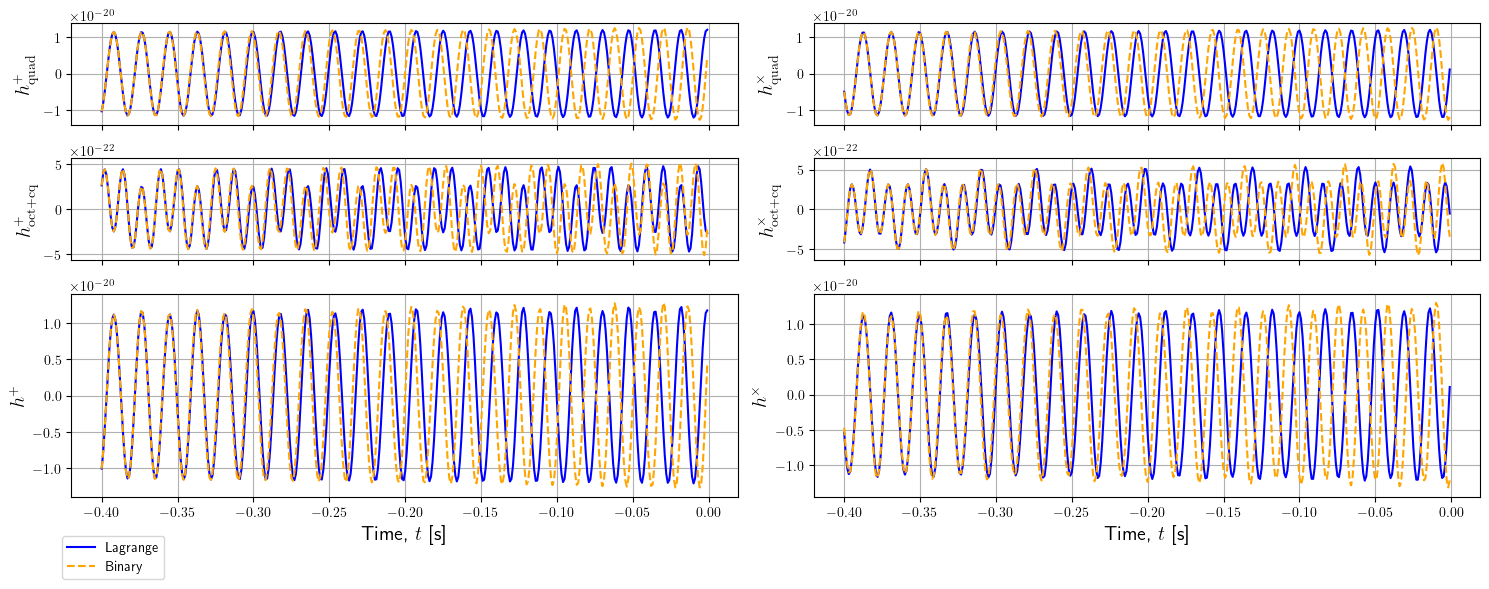

In [66]:
delta_t = 1/1000
t_max = 0.4

params_3B_oct1 = findOctDegeneracy_plus(params_2B_asymm, 1/6, atol = 1e-24)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B_asymm, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time_combined(params_2B_asymm, params_3B_oct1, t_max = t_max, delta_t = delta_t, radRxn = True,
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/Pub - 0.5PN Degeneracy 1.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B_asymm).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct1).t_c))
print("")

print(waveforms.CircularBinary(*params_2B_asymm).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularBinary(*params_2B_asymm).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross") - waveforms.CircularLagrangeTriple(*params_3B_oct1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))

## 0.5PN Quasi-degeneracy

# 3: Scratch

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:61: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:64: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:64: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 1.4433756729740707e-12, m1 = 0.002672917912914973, m2 = 0.002672917912914973, m3 = 0.010691671651659894, r = 5.5685789852396175, i = 29.999999999999996, phi = 4.572448166486045

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 694552.5827683469

[1.0566148e-22 3.1698444e-22]
[1.0566148e-22 3.1698444e-22]
[9.40395481e-38 3.29138418e-37]


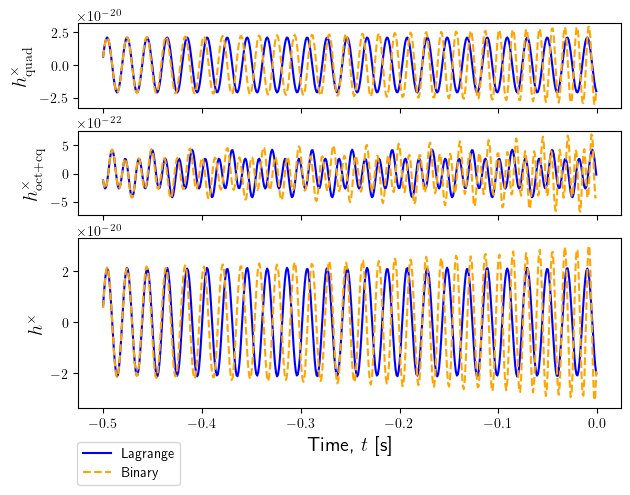

In [240]:
delta_t = 1/1000
t_max = 0.5

params_3B_oct1 = findOctDegeneracy_plus(params_2B, 1/6)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_oct1, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross",
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/Pub - 0.5PN Cross Degeneracy 2.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct1).t_c))
print("")

print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross") - waveforms.CircularLagrangeTriple(*params_3B_oct1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))

In [25]:
for beta_1 in np.linspace(0.15912194481944822, 0.1591219536000439, 100000)[50000:60000]:
    print(beta_1, (find_M_3B(*params_2B, beta_1)/sol)*((beta_1*(1 - 3*beta_1)**2)/(2 - 3*beta_1))**(3/5))

0.15912194920978998 7.7768882353642095
0.15912194920987777 7.7768882023546935
0.15912194920996559 7.776888169345176
0.1591219492100534 7.776888136335652
0.1591219492101412 7.776888103330771
0.159121949210229 7.776888070316623
0.1591219492103168 7.77688803732563
0.15912194921040462 7.776888004311479
0.1591219492104924 7.776887971306596
0.15912194921058023 7.776887938310967
0.15912194921066805 7.776887905292201
0.15912194921075584 7.7768878722873085
0.15912194921084366 7.776887839270849
0.15912194921093145 7.776887806265965
0.15912194921101927 7.776887773261076
0.15912194921110706 7.77688774026082
0.15912194921119488 7.776887707255941
0.1591219492112827 7.776887674237163
0.1591219492113705 7.776887641241539
0.1591219492114583 7.776887608236647
0.1591219492115461 7.77688757523177
0.15912194921163392 7.776887542217627
0.1591219492117217 7.776887509217374
0.15912194921180953 7.776887476203236
0.15912194921189735 7.7768874431937185
0.15912194921198514 7.776887410198108
0.15912194921207296 7.

In [26]:
for beta_1 in np.linspace(0.1591219495130748, 0.15912194951289915, 100000)[1000:1500]:
    print(beta_1, (find_M_3B(*params_2B, beta_1)/sol)*((beta_1*(1 - 3*beta_1)**2)/(2 - 3*beta_1))**(3/5))

0.15912194951307304 7.776774233119908
0.15912194951307304 7.776774233119908
0.15912194951307304 7.776774233119908
0.15912194951307304 7.776774233119908
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.1591

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:61: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:64: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:64: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.309373805332004e-11, m1 = 10.452291790150664, m2 = 10.452291790150664, m3 = 44.78271991324934, r = 6655437.262202962, i = 1.917277536430065, phi = 3.1573163405446967

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.644611819425072



(np.float64(nan), np.float64(nan))

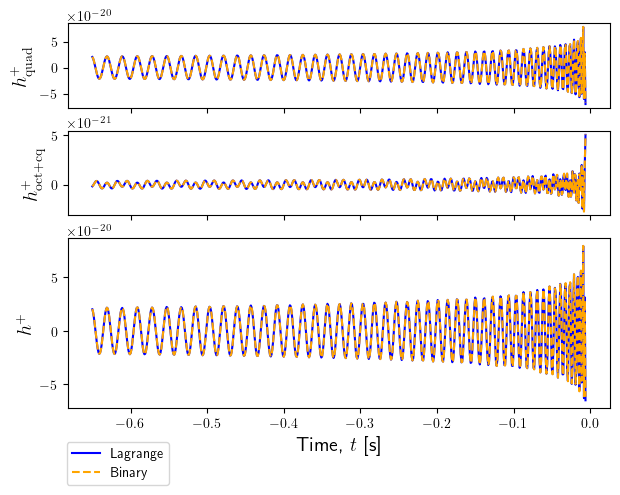

In [224]:
delta_t = 1/1000
t_max = 0.65

params_3B_oct1 = findOctDegeneracy(params_2B, 0.15912194951307287)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_oct1, t_max = t_max, delta_t = delta_t, radRxn = True,
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/Pub - 0.5PN Plus Degeneracy 2.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.2038643766661088e-11, m1 = 9.41970424330016, m2 = 9.41970424330016, m3 = 38.249708139461255, r = 5332841.058608916, i = 1.9010546131127184, phi = 5.572474656817931

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.8314669877874763

[1.0566148e-22 3.1698444e-22]
[1.07574789e-22 3.16333786e-22]
[-1.91330921e-24  6.50653909e-25]


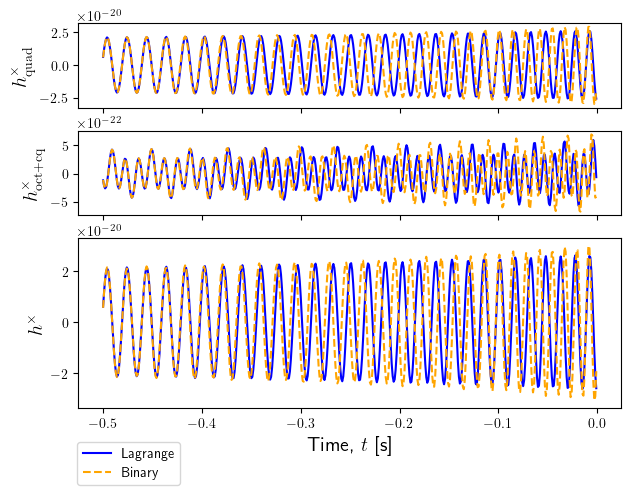

In [112]:
delta_t = 1/1000
t_max = 0.5
params_3B_oct_cross1 = findOctDegeneracy_cross([4e6, 50, 2], *params_2B, beta_1 = 0.165, root_tol = 1e-30, atol = 1e-23)

waveforms.plot_waveform_time(params_2B, params_3B_oct_cross1, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross",
                             size = "vertical",
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/Pub - 0.5PN Cross Degeneracy 1.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).t_c))
print("")

print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross") - waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_60581/3441334345.py:163: RuntimeWarning: invalid value encountered in scalar power
  eq1 = binary.h_quad(1, ampOnly = True, pol = "cross") - 4*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(3*b1 - 1)*np.cos(i_3B)/r_3B


Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 1.8629532364910174e-11, m1 = 5.517274234206001, m2 = 5.517274234206001, m3 = 23.448415495375503, r = 2297575.4406276867, i = 2.337122256515875, phi = 0

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 1.8923727567618707

[1.0566148e-22 3.1698444e-22]
[1.13450859e-22 3.14171609e-22]
[-7.78937898e-24  2.81283049e-24]


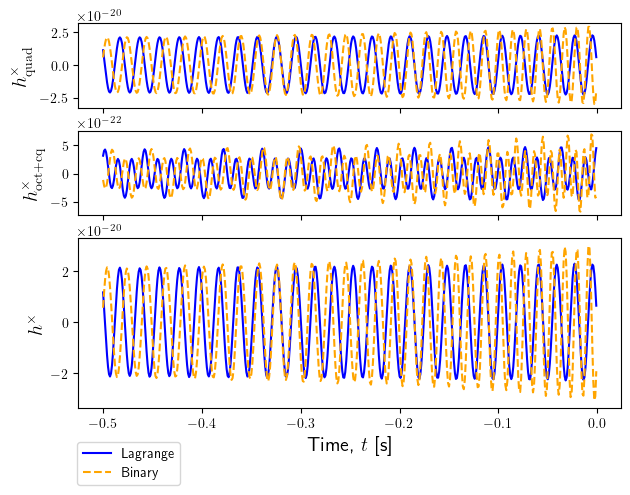

In [218]:
delta_t = 1/1000
t_max = 0.5
params_3B_oct_cross1 = findOctDegeneracy_cross([2.3e6, 50, 1.93], *params_2B, beta_1 = 0.16, root_tol = 1e-30, atol = 1e-24)

waveforms.plot_waveform_time(params_2B, params_3B_oct_cross1, t_max = t_max, delta_t = delta_t, radRxn = True, pol = "cross",
                             size = "vertical",
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/Pub - 0.5PN Cross Degeneracy 2.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).t_c))
print("")

print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))
print(waveforms.CircularBinary(*params_2B).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross") - waveforms.CircularLagrangeTriple(*params_3B_oct_cross1).h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "cross"))